## CITYWALK NAGASAKI TRIAL DATA ANALYTICS (General)

In [139]:
%load_ext autoreload
%autoreload 2
import sys
import math
import random
sys.path.append('../')
from models.history import History, ActionType
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from analysis.analysis import add_action, convert_to_metric, gen_locations_by_user, gen_xys_by_user, draw_path_from_positions, draw

In [46]:
RatingType.__ja__

{0: 'CITYWALKサービス', 1: '施設', 2: '案内コンテンツ'}

In [47]:
%%time
ratings = Rating.find({'rating_type': 1})
df_ratings = pd.DataFrame.from_records(ratings)
df_ratings.head()

CPU times: user 8 ms, sys: 0 ns, total: 8 ms
Wall time: 6.36 ms


,_id,user_id,rating_type,utc_date,rate,comment,facility_id,audio_content_id,created,updated
0,6031a96c4ed7654d57951440,6031a5ccd9436beda2244d20,1,2021-02-21 00:29:32.070,4,,dejima,None,2021-02-21 00:29:32.177,2021-02-21 00:29:32.177
1,6031a76b4f11bb775f75ce48,6031a5896fa21e68fdfa2506,1,2021-02-21 00:20:59.675,3,,dejima,None,2021-02-21 00:20:59.782,2021-02-21 00:20:59.782
2,603361bcaf9cf65fca82f2a1,6030579d38e00b93f961e6f6,1,2021-02-22 07:48:12.942,3,,dejima,None,2021-02-22 07:48:12.969,2021-02-22 07:48:12.969
3,6030e4ae90b6c56b90fd164b,602c71e1ed265c233f4da8c0,1,2021-02-17 01:36:58.166,1,,glovergarden,None,2021-02-20 10:30:06.584,2021-02-20 10:30:06.584
4,60330d79b5471f933ed30116,603305ecaf9cf65fca82f29b,1,2021-02-22 01:48:41.077,2,,glovergarden,None,2021-02-22 01:48:41.201,2021-02-22 01:48:41.201


In [48]:
df_ratings.describe()

,rating_type,rate
count,74.0,74.000000
mean,1.0,2.972973
std,0.0,1.534739
min,1.0,1.000000
25%,1.0,1.000000
50%,1.0,3.000000
75%,1.0,4.000000
max,1.0,5.000000


In [49]:
df_ratings.groupby('rate').count()

,_id,user_id,rating_type,utc_date,comment,facility_id,audio_content_id,created,updated
rate,,,,,,,,,
1,20,20,20,20,20,20,0,20,20
2,10,10,10,10,10,10,0,10,10
3,13,13,13,13,13,13,0,13,13
4,14,14,14,14,14,14,0,14,14
5,17,17,17,17,17,17,0,17,17


<AxesSubplot:title={'center':'user rating'}, ylabel='_id'>

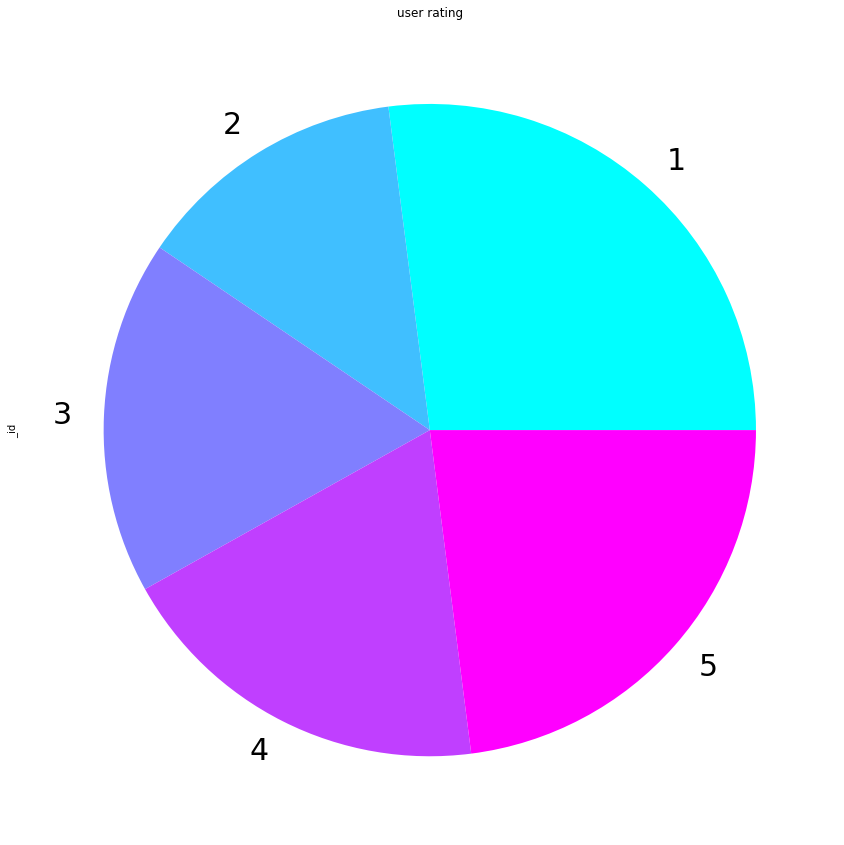

In [50]:
df_ratings.groupby('rate').count()['_id'].plot(kind='pie', figsize=(15, 15), fontsize=30, title='user rating', colormap='cool')

In [51]:
n_rate_5 = len(df_ratings[df_ratings['rate'] == 5])
n_rate_4 = len(df_ratings[df_ratings['rate'] == 4])
n_rate_3 = len(df_ratings[df_ratings['rate'] == 3])
n_rate_2 = len(df_ratings[df_ratings['rate'] == 2])
n_rate_1 = len(df_ratings[df_ratings['rate'] == 1])
rater_count = n_rate_5+ n_rate_4+ n_rate_3+ n_rate_2+ n_rate_1
total = n_rate_5 * 5 + n_rate_4 * 4 + n_rate_3 * 3 + n_rate_2 * 2 + n_rate_1 * 1
ave = total/rater_count
print(f'非常に良い {n_rate_5}')
print(f'良い {n_rate_4}')
print(f'普通 {n_rate_3}')
print(f'あまり良くない {n_rate_2}')
print(f'良くない {n_rate_1}')
print('-------------------------------------')
print(f'平均 {ave:.2f} [票数 {rater_count}]')

非常に良い 17
良い 14
普通 13
あまり良くない 10
良くない 20
-------------------------------------
平均 2.97 [票数 74]


In [52]:
df_ratings[df_ratings['facility_id'] == 'glovergarden'].count()

_id                 22
user_id             22
rating_type         22
utc_date            22
rate                22
comment             22
facility_id         22
audio_content_id     0
created             22
updated             22
dtype: int64

Text(0.5, 1.0, 'rating @glovergarden')

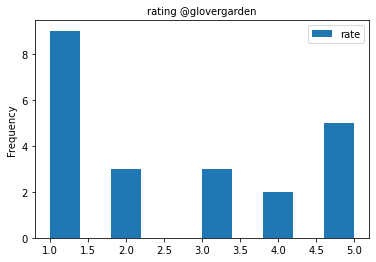

In [53]:
df_ratings[df_ratings['facility_id'] == 'glovergarden'].plot(y='rate', kind='hist')
plt.title(u'rating @glovergarden', size=10)

In [54]:
df_ratings[df_ratings['facility_id'] == 'dejima'].count()

_id                 52
user_id             52
rating_type         52
utc_date            52
rate                52
comment             52
facility_id         52
audio_content_id     0
created             52
updated             52
dtype: int64

Text(0.5, 1.0, 'rating @dejima')

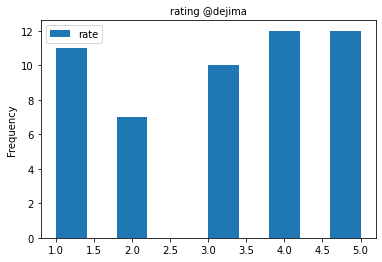

In [55]:
df_ratings[df_ratings['facility_id'] == 'dejima'].plot(y='rate', kind='hist')
plt.title(u'rating @dejima', size=10)

Text(0.5, 1.0, 'rating @iuojima')

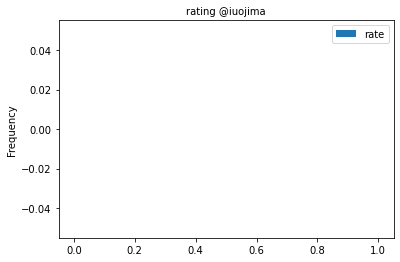

In [56]:
df_ratings[df_ratings['facility_id'] == 'ioujima'].plot(y='rate', kind='hist')
plt.title(u'rating @iuojima', size=10)

In [57]:
ActionType.__ja__

{1: '現在座標更新(GPS)',
 2: '現在座標更新(HGPS)',
 3: '現在座標更新(PATHNET)',
 100: 'アプリケーション起動',
 101: 'アプリケーションバックグラウンド移行',
 102: 'アプリケーション終了',
 200: 'Facility選択',
 300: '案内開始',
 301: '案内終了',
 302: 'チェックイン',
 400: 'コンテンツ再生',
 401: 'コンテンツ停止',
 402: 'コンテンツ再生完了',
 500: '質問に回答'}

#### Audio Content

In [58]:
play_records = History.find({'action_type': ActionType.PLAY_AUDIO_CONTENT.value})

In [59]:
df_play_records = pd.DataFrame.from_records(play_records)
df_play_records.head()

,_id,user_id,action_type,lat,lon,hlat,hlon,hgx,hgy,px,py,utc_date,facility_id,object_id,question_id,answer,check_in_panel_id,created,updated
0,6031a634dc8f83adadb65abf,6031a5896fa21e68fdfa2506,400,None,None,None,None,None,None,None,None,2021-02-21 00:15:48.888000,dejima,None,None,None,None,2021-02-21 00:15:48.988,2021-02-21 00:15:48.988
1,6031a64ad9436beda2244d21,6031a5ccd9436beda2244d20,400,None,None,None,None,None,None,None,None,2021-02-21 00:16:10.325000,dejima,None,None,None,None,2021-02-21 00:16:10.537,2021-02-21 00:16:10.537
2,6031a69eb171081f703e0ca8,6031a5896fa21e68fdfa2506,400,None,None,None,None,None,None,None,None,2021-02-21 00:17:34.029000,dejima,None,None,None,None,2021-02-21 00:17:34.081,2021-02-21 00:17:34.081
3,6031a6a4dc27f588033ebdc2,6031a5ccd9436beda2244d20,400,None,None,None,None,None,None,None,None,2021-02-21 00:17:40.727000,dejima,None,None,None,None,2021-02-21 00:17:40.772,2021-02-21 00:17:40.772
4,6031aa79b171081f703e0caa,6031a9416fa21e68fdfa2507,400,None,None,None,None,None,None,None,None,2021-02-21 00:34:01.149000,dejima,None,None,None,None,2021-02-21 00:34:01.282,2021-02-21 00:34:01.282


In [60]:
df_play_records[['user_id', 'action_type', 'utc_date', 'created']].head()

,user_id,action_type,utc_date,created
0,6031a5896fa21e68fdfa2506,400,2021-02-21 00:15:48.888000,2021-02-21 00:15:48.988
1,6031a5ccd9436beda2244d20,400,2021-02-21 00:16:10.325000,2021-02-21 00:16:10.537
2,6031a5896fa21e68fdfa2506,400,2021-02-21 00:17:34.029000,2021-02-21 00:17:34.081
3,6031a5ccd9436beda2244d20,400,2021-02-21 00:17:40.727000,2021-02-21 00:17:40.772
4,6031a9416fa21e68fdfa2507,400,2021-02-21 00:34:01.149000,2021-02-21 00:34:01.282


In [61]:
# 再生回数ごとのユーザー数分布
x = []
y = []
for i, c in enumerate(df_play_records.groupby('user_id').count().groupby('_id').count()['created'].squeeze()): #.plot(y='created', kind='barh', stacked=True)#.bar()#.plot(y='created', kind='hist')
    print(i+1, c)
    x += [i+1]
    y += [c]

1 106
2 44
3 73
4 8
5 1
6 7


In [62]:
x, y

([1, 2, 3, 4, 5, 6], [106, 44, 73, 8, 1, 7])

In [63]:
def plot_ratingbar(x, y, title, xlabel, ylabel, cmap='nipy_spectral'):
    figsize = (30, 10)
    fontsize = 23
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    ax.xaxis.label.set_color('grey')
    ax.yaxis.label.set_color('grey')
    ax.xaxis.label.set_fontsize(fontsize)
    ax.yaxis.label.set_fontsize(fontsize)
    ax.tick_params(axis='x', colors='grey', labelsize=fontsize)
    ax.tick_params(axis='y', colors='grey', labelsize=fontsize)
    
    width = 0.75 # the width of the bars 
    ind = np.arange(len(y))  # the x locations for the groups
    my_cmap = plt.get_cmap(cmap)
    rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))
    ax.barh(ind, y, width, color=my_cmap(rescale(y)))
    ax.set_yticks(ind+width/2)
    ax.set_yticklabels(x, minor=False)
    plt.title(title, fontsize=23)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)      
    total = sum(y)
    for i, v in enumerate(y):
        rate = ((v+1)/total) * 100
        ax.text(v + 3, i , f'{rate:.1f}%', color='gray', fontweight='bold', fontsize=23)
    #plt.show()
    #plt.savefig(os.path.join('test.png'), dpi=300, format='png', bbox_inches='tight')

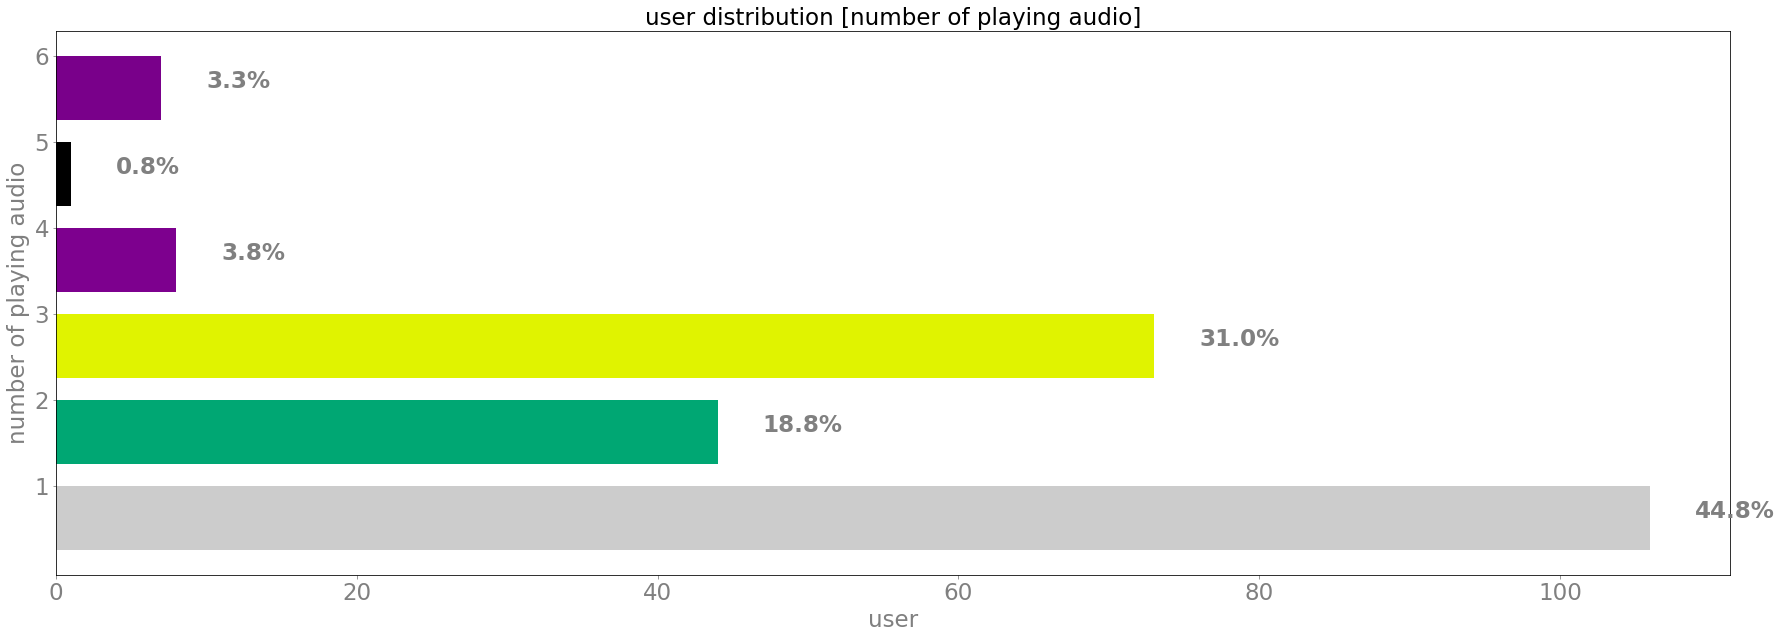

In [64]:
plot_ratingbar(x, y, title='user distribution [number of playing audio]', xlabel='user', ylabel='number of playing audio')

#### average

In [65]:
user_total = sum(y)
user_total

239

In [66]:
play_total = sum([i*j for i,j in zip(x, y)])
play_total

492

In [67]:
play_total / user_total

2.0585774058577404

#### Location

In [68]:
%%time
positions = History.find({'action_type': 1})
df_positions = pd.DataFrame.from_records(positions)
df_positions.head()

CPU times: user 4min 36s, sys: 23.4 s, total: 5min
Wall time: 5min 13s


,_id,user_id,action_type,lat,lon,hlat,hlon,hgx,hgy,px,py,utc_date,facility_id,object_id,question_id,answer,check_in_panel_id,created,updated
0,602b44aa1553695407e3f12b,test,1,0.110000,0.110000,None,None,None,None,None,None,2021-01-31 07:25:08.309000,test,None,None,None,None,2021-02-16 04:06:02.998,2021-02-16 04:06:02.998
1,602d4017ac5bc095d520660a,602c67565485a7db08752a02,1,32.734364,129.869242,None,None,None,None,None,None,2021-02-17 00:47:49.159000,glovergarden,None,None,None,None,2021-02-17 16:11:03.937,2021-02-17 16:11:03.937
2,602d4017ac5bc095d5206607,602c5c2a91e8b51a007bd9ac,1,32.732461,129.869918,None,None,None,None,None,None,2021-02-17 00:47:55.079000,,None,None,None,None,2021-02-17 16:11:03.937,2021-02-17 16:11:03.937
3,602d4017ac5bc095d5206609,602bba068f9200af8dfcea1e,1,32.732495,129.869939,None,None,None,None,None,None,2021-02-17 00:47:52.114000,,None,None,None,None,2021-02-17 16:11:03.937,2021-02-17 16:11:03.937
4,602d4017ac5bc095d5206613,602c67565485a7db08752a02,1,32.734379,129.869255,None,None,None,None,None,None,2021-02-17 00:48:01.161000,glovergarden,None,None,None,None,2021-02-17 16:11:03.993,2021-02-17 16:11:03.993


In [69]:
%%time
user_ids = [user_id for user_id, _ in df_positions.groupby('user_id')]
user_ids

CPU times: user 4.9 s, sys: 928 ms, total: 5.82 s
Wall time: 5.79 s


['602b460b8f9200af8dfcea1b',
 '602b49889712447e9a40ed96',
 '602b49ca5808e746dacecad8',
 '602b596ecd49e073e169858c',
 '602bba068f9200af8dfcea1e',
 '602bcff43c3ff3968e23435d',
 '602c5c2a91e8b51a007bd9ac',
 '602c5c733c460f4c5e699fc0',
 '602c5c7bed265c233f4da8bf',
 '602c62c75485a7db08752a01',
 '602c63669d623a846a2eaf03',
 '602c67565485a7db08752a02',
 '602c67672ddbeaca297172b3',
 '602c68f42ddbeaca297172b4',
 '602c691a0751e911740d8557',
 '602c691ad68a4f8ecf537b45',
 '602c71dd846541ff1adc43df',
 '602c71e1ed265c233f4da8c0',
 '602c8413d68a4f8ecf537b46',
 '602c85279d623a846a2eaf04',
 '602c867612c123edd1b95540',
 '602c8bc54070557252ab6c0b',
 '602c8bf8ed265c233f4da8c1',
 '602c8eab3637c8d1b8e3a6ba',
 '602c8eb0ed265c233f4da8c2',
 '602c909fd68a4f8ecf537b47',
 '602c912e846541ff1adc43e0',
 '602c92667bd4bab733388014',
 '602c92831fd6832f4b311216',
 '602c92b27e16a082bd456423',
 '602c9362d68a4f8ecf537b48',
 '602c9397ed265c233f4da8c3',
 '602c93afa3891bf808f7b010',
 '602c94382e9dfa58bfbb5526',
 '602c94543d2c

In [70]:
df_positions_user_sorted = df_positions.groupby('user_id').get_group('6031a5896fa21e68fdfa2506')#.sort_values(by=['utc_date'])
df_positions_user_sorted

,_id,user_id,action_type,lat,lon,hlat,hlon,hgx,hgy,px,py,utc_date,facility_id,object_id,question_id,answer,check_in_panel_id,created,updated
1296002,6031a58e8803ac64e2253b14,6031a5896fa21e68fdfa2506,1,32.743722,129.872956,None,None,None,None,None,None,2021-02-21 00:13:00.409000,,None,None,None,None,2021-02-21 00:13:02.803,2021-02-21 00:13:02.803
1296012,6031a5918803ac64e2253b26,6031a5896fa21e68fdfa2506,1,32.743688,129.873046,None,None,None,None,None,None,2021-02-21 00:13:05.269000,,None,None,None,None,2021-02-21 00:13:05.348,2021-02-21 00:13:05.348
1296014,6031a59254a8d53f49c3a5ac,6031a5896fa21e68fdfa2506,1,32.743686,129.873052,None,None,None,None,None,None,2021-02-21 00:13:06.146000,,None,None,None,None,2021-02-21 00:13:06.236,2021-02-21 00:13:06.236
1296017,6031a59354a8d53f49c3a5ae,6031a5896fa21e68fdfa2506,1,32.743679,129.873050,None,None,None,None,None,None,2021-02-21 00:13:07.146000,,None,None,None,None,2021-02-21 00:13:07.231,2021-02-21 00:13:07.231
1296025,6031a59454a8d53f49c3a5b1,6031a5896fa21e68fdfa2506,1,32.743662,129.873046,None,None,None,None,None,None,2021-02-21 00:13:08.152000,,None,None,None,None,2021-02-21 00:13:08.230,2021-02-21 00:13:08.230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5204447,603bb2c29c90eb611254790b,6031a5896fa21e68fdfa2506,1,33.174959,129.672831,None,None,None,None,None,None,2021-02-28 15:11:57.939000,,None,None,None,None,2021-02-28 15:12:02.652,2021-02-28 15:12:02.652
5204463,603bb2c2c9599d1cb38db033,6031a5896fa21e68fdfa2506,1,33.174960,129.672830,None,None,None,None,None,None,2021-02-28 15:11:59.251000,,None,None,None,None,2021-02-28 15:12:02.667,2021-02-28 15:12:02.667
5204464,603bb2c2c9599d1cb38db036,6031a5896fa21e68fdfa2506,1,33.174984,129.672908,None,None,None,None,None,None,2021-02-28 15:11:59.652000,,None,None,None,None,2021-02-28 15:12:02.667,2021-02-28 15:12:02.667
5204466,603bb2c29c90eb611254790a,6031a5896fa21e68fdfa2506,1,33.175271,129.672515,None,None,None,None,None,None,2021-02-28 15:11:57.515000,,None,None,None,None,2021-02-28 15:12:02.652,2021-02-28 15:12:02.652


In [71]:
plays = df_play_records[df_play_records['user_id'] == '6031a5896fa21e68fdfa2506']
plays

,_id,user_id,action_type,lat,lon,hlat,hlon,hgx,hgy,px,py,utc_date,facility_id,object_id,question_id,answer,check_in_panel_id,created,updated
0,6031a634dc8f83adadb65abf,6031a5896fa21e68fdfa2506,400,None,None,None,None,None,None,None,None,2021-02-21 00:15:48.888000,dejima,None,None,None,None,2021-02-21 00:15:48.988,2021-02-21 00:15:48.988
2,6031a69eb171081f703e0ca8,6031a5896fa21e68fdfa2506,400,None,None,None,None,None,None,None,None,2021-02-21 00:17:34.029000,dejima,None,None,None,None,2021-02-21 00:17:34.081,2021-02-21 00:17:34.081
6,6031b069b171081f703e0cac,6031a5896fa21e68fdfa2506,400,None,None,None,None,None,None,None,None,2021-02-21 00:59:21.521000,dejima,None,None,None,None,2021-02-21 00:59:21.621,2021-02-21 00:59:21.621


In [72]:
for idx, play in plays.iterrows():
    print(play)

_id                    6031a634dc8f83adadb65abf
user_id                6031a5896fa21e68fdfa2506
action_type                                 400
lat                                        None
lon                                        None
hlat                                       None
hlon                                       None
hgx                                        None
hgy                                        None
px                                         None
py                                         None
utc_date             2021-02-21 00:15:48.888000
facility_id                              dejima
object_id                                  None
question_id                                None
answer                                     None
check_in_panel_id                          None
created              2021-02-21 00:15:48.988000
updated              2021-02-21 00:15:48.988000
Name: 0, dtype: object
_id                    6031a69eb171081f703e0ca8
user_id          

In [73]:
play_2 = df_play_records[df_play_records['user_id'] == '6031a5896fa21e68fdfa2506'].iloc[2]
play_2

_id                    6031b069b171081f703e0cac
user_id                6031a5896fa21e68fdfa2506
action_type                                 400
lat                                        None
lon                                        None
hlat                                       None
hlon                                       None
hgx                                        None
hgy                                        None
px                                         None
py                                         None
utc_date             2021-02-21 00:59:21.521000
facility_id                              dejima
object_id                                  None
question_id                                None
answer                                     None
check_in_panel_id                          None
created              2021-02-21 00:59:21.621000
updated              2021-02-21 00:59:21.621000
Name: 6, dtype: object

In [74]:
play_2['utc_date']

datetime.datetime(2021, 2, 21, 0, 59, 21, 521000)

In [75]:
def diff_sec(t1, t2):
    dif = (t1 - t2)
    return abs(dif.seconds)

In [76]:
df_positions_user_sorted['utc_date']

1296002    2021-02-21 00:13:00.409000
1296012    2021-02-21 00:13:05.269000
1296014    2021-02-21 00:13:06.146000
1296017    2021-02-21 00:13:07.146000
1296025    2021-02-21 00:13:08.152000
                      ...            
5204447    2021-02-28 15:11:57.939000
5204463    2021-02-28 15:11:59.251000
5204464    2021-02-28 15:11:59.652000
5204466    2021-02-28 15:11:57.515000
5204469    2021-02-28 15:11:57.416000
Name: utc_date, Length: 2676, dtype: object

In [77]:
i = df_positions_user_sorted['utc_date'].searchsorted(play_2['utc_date'])
df_positions_user_sorted.iloc[i]

_id                    6031b0959cf136b82ad5a3ff
user_id                6031a5896fa21e68fdfa2506
action_type                                   1
lat                                   32.743352
lon                                  129.873259
hlat                                       None
hlon                                       None
hgx                                        None
hgy                                        None
px                                         None
py                                         None
utc_date             2021-02-21 00:59:21.540000
facility_id                              dejima
object_id                                  None
question_id                                None
answer                                     None
check_in_panel_id                          None
created              2021-02-21 01:00:05.177000
updated              2021-02-21 01:00:05.177000
Name: 1319556, dtype: object

In [78]:
df_positions_user_sorted.loc[:, 'action'] = 0

/home/kaz/Sources/citywalkservers/www/venv/lib/python3.7/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/home/kaz/Sources/citywalkservers/www/venv/lib/python3.7/site-packages/pandas/core/indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


In [79]:
df_positions_user_sorted['action'].iloc[i] = ActionType.PLAY_AUDIO_CONTENT.value
df_positions_user_sorted['action'].iloc[i]

/home/kaz/Sources/citywalkservers/www/venv/lib/python3.7/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/home/kaz/Sources/citywalkservers/www/venv/lib/python3.7/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value, self.name)


400

In [80]:
df_positions.head()

,_id,user_id,action_type,lat,lon,hlat,hlon,hgx,hgy,px,py,utc_date,facility_id,object_id,question_id,answer,check_in_panel_id,created,updated
0,602b44aa1553695407e3f12b,test,1,0.110000,0.110000,None,None,None,None,None,None,2021-01-31 07:25:08.309000,test,None,None,None,None,2021-02-16 04:06:02.998,2021-02-16 04:06:02.998
1,602d4017ac5bc095d520660a,602c67565485a7db08752a02,1,32.734364,129.869242,None,None,None,None,None,None,2021-02-17 00:47:49.159000,glovergarden,None,None,None,None,2021-02-17 16:11:03.937,2021-02-17 16:11:03.937
2,602d4017ac5bc095d5206607,602c5c2a91e8b51a007bd9ac,1,32.732461,129.869918,None,None,None,None,None,None,2021-02-17 00:47:55.079000,,None,None,None,None,2021-02-17 16:11:03.937,2021-02-17 16:11:03.937
3,602d4017ac5bc095d5206609,602bba068f9200af8dfcea1e,1,32.732495,129.869939,None,None,None,None,None,None,2021-02-17 00:47:52.114000,,None,None,None,None,2021-02-17 16:11:03.937,2021-02-17 16:11:03.937
4,602d4017ac5bc095d5206613,602c67565485a7db08752a02,1,32.734379,129.869255,None,None,None,None,None,None,2021-02-17 00:48:01.161000,glovergarden,None,None,None,None,2021-02-17 16:11:03.993,2021-02-17 16:11:03.993


In [81]:
from analysis.analysis import add_action

In [82]:
df_positions.loc[:, 'action'] = 0

In [83]:
df_positions_with_action = add_action(df_positions, df_play_records, ActionType.PLAY_AUDIO_CONTENT.value)

  0%|          | 0/1097 [00:00<?, ?it/s]

1097 users found
user_id 602b460b8f9200af8dfcea1b


  0%|          | 1/1097 [00:01<29:19,  1.61s/it]

user_id 602b49889712447e9a40ed96


  0%|          | 2/1097 [00:03<29:21,  1.61s/it]

...

100%|█████████▉| 1095/1097 [30:59<00:03,  1.66s/it]

user_id bakubaku


100%|█████████▉| 1096/1097 [31:01<00:01,  1.66s/it]

user_id test


100%|██████████| 1097/1097 [31:02<00:00,  1.70s/it]


In [84]:
df_positions_with_action[df_positions_with_action['action'] == ActionType.PLAY_AUDIO_CONTENT.value].count()

_id                  492
user_id              492
action_type          492
lat                  492
lon                  492
hlat                   0
hlon                   0
hgx                    0
hgy                    0
px                     0
py                     0
utc_date             492
facility_id          492
object_id              0
question_id            0
answer                 0
check_in_panel_id      0
created              492
updated              492
action               492
dtype: int64

In [85]:
df_positions_with_action

,_id,user_id,action_type,lat,lon,hlat,hlon,hgx,hgy,px,py,utc_date,facility_id,object_id,question_id,answer,check_in_panel_id,created,updated,action
2086,602d408f398fbc24fc128e52,602b460b8f9200af8dfcea1b,1,32.742890,129.876723,None,None,None,None,None,None,2021-02-16 04:11:55.637000,,None,None,None,None,2021-02-17 16:13:03.264,2021-02-17 16:13:03.264,0
2183,602d408f398fbc24fc128eb7,602b460b8f9200af8dfcea1b,1,32.742929,129.876707,None,None,None,None,None,None,2021-02-16 03:41:31.934000,,None,None,None,None,2021-02-17 16:13:03.877,2021-02-17 16:13:03.877,0
3442,602d40cc0544906bf881d165,602b460b8f9200af8dfcea1b,1,32.742915,129.876682,None,None,None,None,None,None,2021-02-16 03:40:16.312000,,None,None,None,None,2021-02-17 16:14:04.736,2021-02-17 16:14:04.736,0
5119,602d4143aa32ac43bb042639,602b460b8f9200af8dfcea1b,1,32.742904,129.876658,None,None,None,None,None,None,2021-02-16 04:11:55.645000,,None,None,None,None,2021-02-17 16:16:03.334,2021-02-17 16:16:03.334,0
10155,602d42abb670292fecb0888f,602b460b8f9200af8dfcea1b,1,32.742912,129.876739,None,None,None,None,None,None,2021-02-16 04:12:22.665000,,None,None,None,None,2021-02-17 16:22:03.742,2021-02-17 16:22:03.742,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12536158,604c95575ca0e017ed6f7a58,604c799c9f229ce7ac81e11e,1,32.743915,129.873203,None,None,None,None,None,None,2021-03-13 08:49:08.084000,,None,None,None,None,2021-03-13 10:35:03.883,2021-03-13 10:35:03.883,0
12536159,604c95575ca0e017ed6f7a5b,604c799c9f229ce7ac81e11e,1,32.744031,129.873129,None,None,None,None,None,None,2021-03-13 08:49:21.080000,,None,None,None,None,2021-03-13 10:35:03.883,2021-03-13 10:35:03.883,0
12536193,604c95575ca0e017ed6f7a80,604c799c9f229ce7ac81e11e,1,32.743983,129.873217,None,None,None,None,None,None,2021-03-13 08:49:14.083000,,None,None,None,None,2021-03-13 10:35:03.993,2021-03-13 10:35:03.993,0
6018639,603e7f03b0737066756e51ef,bakubaku,1,45.000000,123.000000,None,None,None,None,None,None,2021-02-17 01:36:58.166000,hogehoge,None,None,None,None,2021-03-02 18:08:03.454,2021-03-02 18:08:03.454,0


In [86]:
df_finish_guide = pd.DataFrame.from_records(History.find({'action_type': ActionType.FINISH_GUIDE.value}))
df_finish_guide

,_id,user_id,action_type,lat,lon,hlat,hlon,hgx,hgy,px,py,utc_date,facility_id,object_id,question_id,answer,check_in_panel_id,created,updated
0,6031b08edc8f83adadb65ac1,6031a5ccd9436beda2244d20,301,None,None,None,None,None,None,None,None,2021-02-21 00:59:58.020,dejima,None,None,None,None,2021-02-21 00:59:58.130,2021-02-21 00:59:58.130
1,6031b09b5f0559659fe8bcd0,6031a5896fa21e68fdfa2506,301,None,None,None,None,None,None,None,None,2021-02-21 01:00:11.587,dejima,None,None,None,None,2021-02-21 01:00:11.689,2021-02-21 01:00:11.689
2,6031bd22dc8f83adadb65ac2,6031b55383bbaa740261dc34,301,None,None,None,None,None,None,None,None,2021-02-21 01:53:38.615,dejima,None,None,None,None,2021-02-21 01:53:38.676,2021-02-21 01:53:38.676
3,6031d354d9436beda2244d2d,6031c647ea415dde349f4df8,301,None,None,None,None,None,None,None,None,2021-02-21 03:28:20.672,dejima,None,None,None,None,2021-02-21 03:28:20.732,2021-02-21 03:28:20.732
4,6031f1c3b171081f703e0cce,6031e2e1dc8f83adadb65ad3,301,None,None,None,None,None,None,None,None,2021-02-21 05:38:11.190,dejima,None,None,None,None,2021-02-21 05:38:11.279,2021-02-21 05:38:11.279
5,60334197dc8f83adadb65af3,603338ba07852dc1c878d542,301,None,None,None,None,None,None,None,None,2021-02-22 05:31:03.111,dejima,None,None,None,None,2021-02-22 05:31:03.170,2021-02-22 05:31:03.170
6,6033442ccfad8344d00d188d,603305ecaf9cf65fca82f29b,301,None,None,None,None,None,None,None,None,2021-02-22 05:42:04.867,dejima,None,None,None,None,2021-02-22 05:42:04.914,2021-02-22 05:42:04.914
7,603361f0d56eb723585b57b5,6030579d38e00b93f961e6f6,301,None,None,None,None,None,None,None,None,2021-02-22 07:49:04.582,dejima,None,None,None,None,2021-02-22 07:49:04.618,2021-02-22 07:49:04.618
8,60346ddd6fa21e68fdfa2524,6034625f78ea16060643d316,301,None,None,None,None,None,None,None,None,2021-02-23 02:52:13.364,glovergarden,None,None,None,None,2021-02-23 02:52:13.415,2021-02-23 02:52:13.415
9,6034750fefd2ef1394065cb2,60346a06a5ddafbdfe3e08f6,301,None,None,None,None,None,None,None,None,2021-02-23 03:22:55.605,glovergarden,None,None,None,None,2021-02-23 03:22:55.704,2021-02-23 03:22:55.704


In [87]:
df_finish_guide.groupby('facility_id').count()

,_id,user_id,action_type,lat,lon,hlat,hlon,hgx,hgy,px,py,utc_date,object_id,question_id,answer,check_in_panel_id,created,updated
facility_id,,,,,,,,,,,,,,,,,,
dejima,24,24,24,0,0,0,0,0,0,0,0,24,0,0,0,0,24,24
glovergarden,5,5,5,0,0,0,0,0,0,0,0,5,0,0,0,0,5,5


In [88]:
x = df_finish_guide.groupby('facility_id').count().index.values
x

array(['dejima', 'glovergarden'], dtype=object)

In [89]:
y = df_finish_guide.groupby('facility_id').count().values[:,0]
y

array([24,  5])

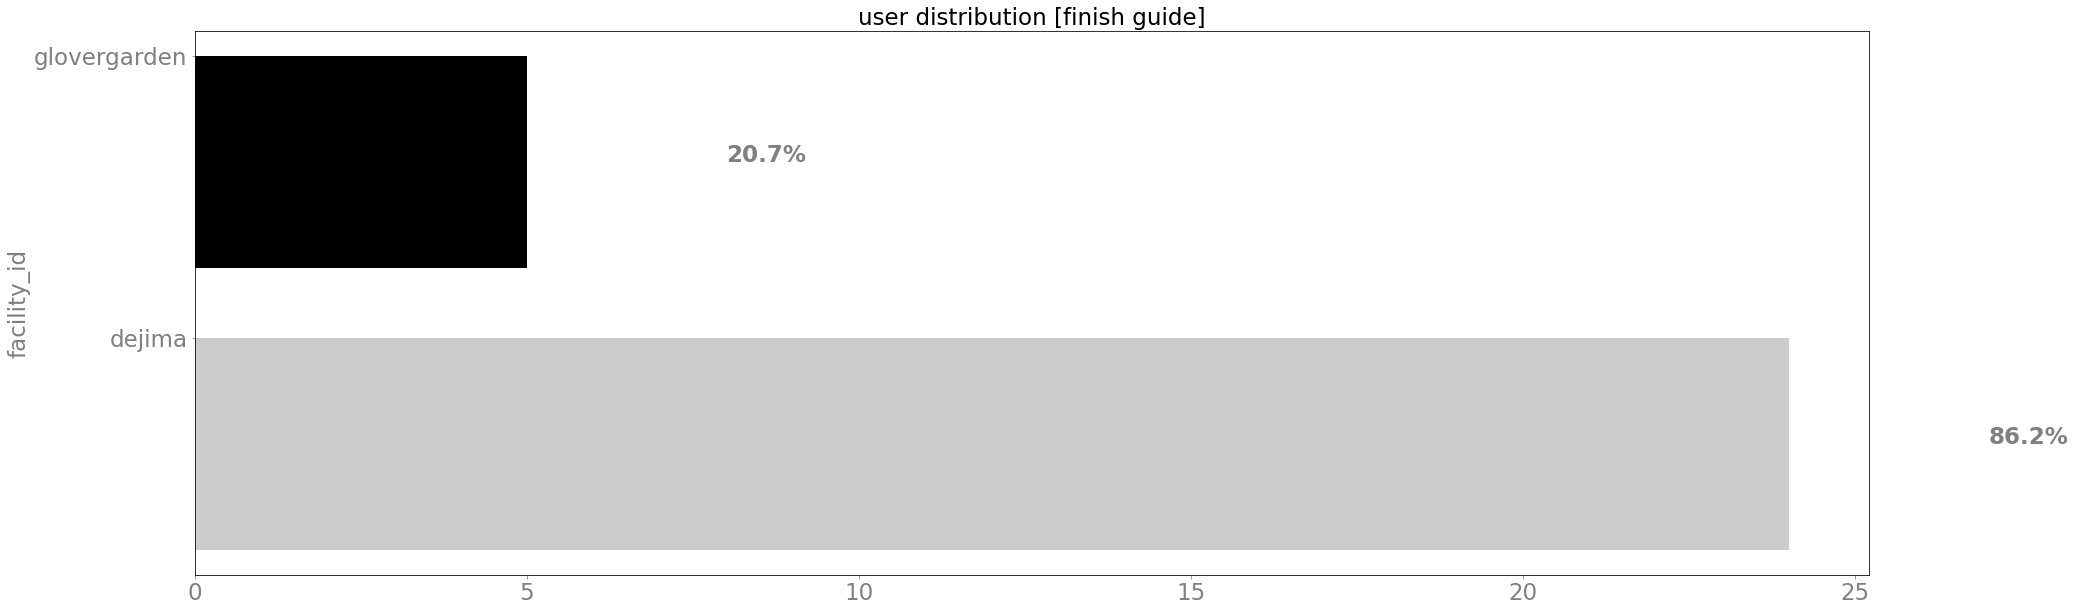

In [90]:
plot_ratingbar(x, y, title='user distribution [finish guide]', xlabel='', ylabel='facility_id')

#### guide points distances

dejima_center_lat = 
dejima_center_lon = 
dejima_

In [91]:
%%time
df_positions = df_positions[['user_id', 'lat', 'lon', 'utc_date', 'facility_id', 'created']]

CPU times: user 552 ms, sys: 284 ms, total: 836 ms
Wall time: 823 ms


In [92]:
%%time
df_positions_glovergarden = df_positions[df_positions['facility_id']  == "glovergarden"]
df_positions_dejima = df_positions[df_positions['facility_id']  == "dejima"]
df_positions_ioujima = df_positions[df_positions['facility_id']  == "ioujima"]
df_positions_others = df_positions[df_positions['facility_id'] == '']

CPU times: user 3.85 s, sys: 352 ms, total: 4.2 s
Wall time: 4.18 s


In [93]:
df_positions_glovergarden.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 393896 entries, 1 to 12396419
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   user_id      393896 non-null  object        
 1   lat          393896 non-null  float64       
 2   lon          393896 non-null  float64       
 3   utc_date     393896 non-null  object        
 4   facility_id  393896 non-null  object        
 5   created      393896 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 21.0+ MB


In [94]:
df_positions_dejima.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 470551 entries, 19614 to 12530854
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   user_id      470551 non-null  object        
 1   lat          470551 non-null  float64       
 2   lon          470551 non-null  float64       
 3   utc_date     470551 non-null  object        
 4   facility_id  470551 non-null  object        
 5   created      470551 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 25.1+ MB


In [95]:
df_positions_ioujima.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3722 entries, 2327 to 9800078
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      3722 non-null   object        
 1   lat          3722 non-null   float64       
 2   lon          3722 non-null   float64       
 3   utc_date     3722 non-null   object        
 4   facility_id  3722 non-null   object        
 5   created      3722 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 203.5+ KB


In [96]:
df_positions_others.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11807596 entries, 2 to 12675766
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   user_id      object        
 1   lat          float64       
 2   lon          float64       
 3   utc_date     object        
 4   facility_id  object        
 5   created      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 630.6+ MB


In [97]:
df_positions_all = pd.concat([df_positions_dejima, df_positions_ioujima, df_positions_glovergarden, df_positions_others])
df_positions_all.head()

,user_id,lat,lon,utc_date,facility_id,created
19614,602c67672ddbeaca297172b3,32.743605,129.873149,2021-02-17 03:19:41.281000,dejima,2021-02-17 16:27:04.470
19640,602c67672ddbeaca297172b3,32.743675,129.873077,2021-02-17 03:19:53.291000,dejima,2021-02-17 16:27:04.630
19748,602c67672ddbeaca297172b3,32.743553,129.873189,2021-02-17 03:21:29.322000,dejima,2021-02-17 16:27:04.776
20804,602c67672ddbeaca297172b3,32.743416,129.873639,2021-02-17 03:30:04.208000,dejima,2021-02-17 16:27:07.550
20806,602c67672ddbeaca297172b3,32.743882,129.873916,2021-02-17 03:30:02.635000,dejima,2021-02-17 16:27:07.549


In [98]:
df_positions_all.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12675765 entries, 19614 to 12675766
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   user_id      object        
 1   lat          float64       
 2   lon          float64       
 3   utc_date     object        
 4   facility_id  object        
 5   created      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 677.0+ MB


In [110]:
df_dejima = df_positions_all[df_positions_all['facility_id'] == 'dejima']
df_dejima

,user_id,lat,lon,utc_date,facility_id,created
19614,602c67672ddbeaca297172b3,32.743605,129.873149,2021-02-17 03:19:41.281000,dejima,2021-02-17 16:27:04.470
19640,602c67672ddbeaca297172b3,32.743675,129.873077,2021-02-17 03:19:53.291000,dejima,2021-02-17 16:27:04.630
19748,602c67672ddbeaca297172b3,32.743553,129.873189,2021-02-17 03:21:29.322000,dejima,2021-02-17 16:27:04.776
20804,602c67672ddbeaca297172b3,32.743416,129.873639,2021-02-17 03:30:04.208000,dejima,2021-02-17 16:27:07.550
20806,602c67672ddbeaca297172b3,32.743882,129.873916,2021-02-17 03:30:02.635000,dejima,2021-02-17 16:27:07.549
...,...,...,...,...,...,...
12530720,604c70db338d79db49b05f33,32.743906,129.873192,2021-03-13 08:40:05.098000,dejima,2021-03-13 10:29:05.253
12530786,604c70db338d79db49b05f33,32.743960,129.873236,2021-03-13 08:40:11.088000,dejima,2021-03-13 10:30:02.863
12530796,604c70db338d79db49b05f33,32.743932,129.873210,2021-03-13 08:40:08.077000,dejima,2021-03-13 10:30:02.930
12530852,604c70db338d79db49b05f33,32.743910,129.873383,2021-03-13 08:40:23.073000,dejima,2021-03-13 10:30:03.207


In [111]:
df_glovergarden = df_positions_all[df_positions_all['facility_id'] == 'glovergarden']
df_glovergarden

,user_id,lat,lon,utc_date,facility_id,created
1,602c67565485a7db08752a02,32.734364,129.869242,2021-02-17 00:47:49.159000,glovergarden,2021-02-17 16:11:03.937
4,602c67565485a7db08752a02,32.734379,129.869255,2021-02-17 00:48:01.161000,glovergarden,2021-02-17 16:11:03.993
5,602c691ad68a4f8ecf537b45,32.732602,129.869939,2021-02-17 01:11:45.073000,glovergarden,2021-02-17 16:11:04.145
9,602c67565485a7db08752a02,32.734374,129.869253,2021-02-17 00:48:00.162000,glovergarden,2021-02-17 16:11:03.993
16,602c691ad68a4f8ecf537b45,32.732602,129.869939,2021-02-17 01:11:48.072000,glovergarden,2021-02-17 16:11:04.186
...,...,...,...,...,...,...
12395488,604c64f72dc80b1d4d6f1cb5,32.733598,129.869633,2021-03-13 07:10:52.053000,glovergarden,2021-03-13 08:14:04.324
12395592,604c64f72dc80b1d4d6f1cb5,32.733598,129.869633,2021-03-13 07:10:59.069000,glovergarden,2021-03-13 08:14:04.573
12395815,604c64f72dc80b1d4d6f1cb5,32.733613,129.869642,2021-03-13 07:11:06.194000,glovergarden,2021-03-13 08:15:02.811
12395942,604c64f72dc80b1d4d6f1cb5,32.733613,129.869642,2021-03-13 07:11:12.073000,glovergarden,2021-03-13 08:15:03.168


In [112]:
df_ioujima = df_positions_all[df_positions_all['facility_id'] == 'ioujima']
df_ioujima

,user_id,lat,lon,utc_date,facility_id,created
2327,602c5c733c460f4c5e699fc0,35.663404,139.903749,2021-02-17 00:00:19.067000,ioujima,2021-02-17 16:13:04.585
3246,602c5c733c460f4c5e699fc0,35.663477,139.903785,2021-02-17 00:00:24.064000,ioujima,2021-02-17 16:14:03.824
4092,602c5c733c460f4c5e699fc0,35.663587,139.903787,2021-02-17 00:00:26.067000,ioujima,2021-02-17 16:15:03.328
13357,602c5c733c460f4c5e699fc0,35.663412,139.903769,2021-02-17 00:00:20.066000,ioujima,2021-02-17 16:24:03.737
13374,602c5c733c460f4c5e699fc0,35.663429,139.903639,2021-02-17 00:00:16.056000,ioujima,2021-02-17 16:24:03.775
...,...,...,...,...,...,...
9800032,604703105ac48e00a2d0fa91,32.706029,129.778375,2021-03-09 14:10:46.342000,ioujima,2021-03-09 14:11:03.306
9800044,604703105ac48e00a2d0fa91,32.705952,129.778383,2021-03-09 14:10:55.345000,ioujima,2021-03-09 14:11:03.331
9800045,604703105ac48e00a2d0fa91,32.705952,129.778383,2021-03-09 14:10:53.345000,ioujima,2021-03-09 14:11:03.361
9800071,604703105ac48e00a2d0fa91,32.706022,129.778375,2021-03-09 14:10:45.338000,ioujima,2021-03-09 14:11:03.361


In [99]:
center_lat = 32.721333 # 女神大橋中央
center_lon = 129.849488 # 女神大橋中央
ngs_lefttop_lat = 32.773216 # 原爆資料館北
ngs_lefttop_lon = 129.758746 # 伊王島東端
ngs_rightbottom_lat = 32.687598 # 伊王島南端 
ngs_rightbottom_lon = 129.886766 # 亀山社中記念館
ioujima_lefttop_lat = 32.715549
ioujima_lefttop_lon = 129.758746
ioujima_rightbottom_lat = 32.687598
ioujima_rightbottom_lon = 129.785530
glovergarden_lefttop_lat = 32.735095
glovergarden_lefttop_lon = 129.867891
glovergarden_rightbottom_lat = 32.731887
glovergarden_rightbottom_lon = 129.870194
dejima_lefttop_lat = 32.744345
dejima_lefttop_lon = 129.871820
dejima_rightbottom_lat = 32.742882
dejima_rightbottom_lon = 129.874052

#### from dejima

In [123]:
n_dejima = len(df_dejima.groupby('user_id').count())
n_dejima

166

In [120]:
lat_min = glovergarden_rightbottom_lat
lat_max = glovergarden_lefttop_lat
lon_min = glovergarden_lefttop_lon
lon_max = glovergarden_rightbottom_lon

n_dejima_to_glover = len(df_dejima[(df_dejima['lat'] > lat_min) & (df_dejima['lat'] < lat_max) & (df_dejima['lon'] > lon_min) & (df_dejima['lon'] < lon_max)].groupby('user_id').count())
n_dejima_to_glover

4

In [124]:
# dejima to glovergarden visiting rate
(n_dejima_to_glover/ n_dejima )*100

2.4096385542168677

In [125]:
lat_min = ioujima_rightbottom_lat
lat_max = ioujima_lefttop_lat
lon_min = ioujima_lefttop_lon
lon_max = ioujima_rightbottom_lon

n_dejima_to_ioujima = len(df_dejima[(df_dejima['lat'] > lat_min) & (df_dejima['lat'] < lat_max) & (df_dejima['lon'] > lon_min) & (df_dejima['lon'] < lon_max)].groupby('user_id').count())
n_dejima_to_ioujima

1

In [136]:
# dejima to ioujima visiting rate
(n_dejima_to_ioujima/n_dejima)*100

0.6024096385542169

#### from glovergarden

In [127]:
n_glovergarden = len(df_glovergarden.groupby('user_id').count())
n_glovergarden

212

In [128]:
lat_min = dejima_rightbottom_lat
lat_max = dejima_lefttop_lat
lon_min = dejima_lefttop_lon
lon_max = dejima_rightbottom_lon

n_glovergarden_to_dejima = len(df_glovergarden[(df_glovergarden['lat'] > lat_min) & (df_glovergarden['lat'] < lat_max) & (df_glovergarden['lon'] > lon_min) & (df_glovergarden['lon'] < lon_max)].groupby('user_id').count())
n_glovergarden_to_dejima

11

In [137]:
# glovergarden to dejima visiting rate
(n_glovergarden_to_dejima/n_glovergarden)*100

5.188679245283019

In [130]:
lat_min = ioujima_rightbottom_lat
lat_max = ioujima_lefttop_lat
lon_min = ioujima_lefttop_lon
lon_max = ioujima_rightbottom_lon

n_glovergarden_to_ioujima = len(df_glovergarden[(df_glovergarden['lat'] > lat_min) & (df_glovergarden['lat'] < lat_max) & (df_glovergarden['lon'] > lon_min) & (df_glovergarden['lon'] < lon_max)].groupby('user_id').count())
n_glovergarden_to_ioujima

0

In [138]:
# glovergarden to ioujima visiting rate
(n_glovergarden_to_ioujima/n_glovergarden)*100

0.0

#### from ioujima

In [133]:
n_ioujima = len(df_ioujima.groupby('user_id').count())
n_ioujima

17

In [134]:
lat_min = glovergarden_rightbottom_lat
lat_max = glovergarden_lefttop_lat
lon_min = glovergarden_lefttop_lon
lon_max = glovergarden_rightbottom_lon

n_ioujima_to_glover = len(df_ioujima[(df_ioujima['lat'] > lat_min) & (df_ioujima['lat'] < lat_max) & (df_ioujima['lon'] > lon_min) & (df_ioujima['lon'] < lon_max)].groupby('user_id').count())
n_ioujima_to_glover

0

In [135]:
lat_min = dejima_rightbottom_lat
lat_max = dejima_lefttop_lat
lon_min = dejima_lefttop_lon
lon_max = dejima_rightbottom_lon

n_ioujima_to_dejima = len(df_ioujima[(df_ioujima['lat'] > lat_min) & (df_ioujima['lat'] < lat_max) & (df_ioujima['lon'] > lon_min) & (df_ioujima['lon'] < lon_max)].groupby('user_id').count())
n_ioujima_to_dejima

0

In [100]:
min_lat = ngs_rightbottom_lat
min_lon = ngs_lefttop_lon
max_lat = ngs_lefttop_lat
max_lon = ngs_rightbottom_lon
df_positions_nagasaki = df_positions_all[(df_positions_all['lat'] > min_lat) & (df_positions_all['lon'] > min_lon) & (df_positions_all['lat'] < max_lat) & (df_positions_all['lon'] < max_lon)]
df_positions_nagasaki

,user_id,lat,lon,utc_date,facility_id,created
19614,602c67672ddbeaca297172b3,32.743605,129.873149,2021-02-17 03:19:41.281000,dejima,2021-02-17 16:27:04.470
19640,602c67672ddbeaca297172b3,32.743675,129.873077,2021-02-17 03:19:53.291000,dejima,2021-02-17 16:27:04.630
19748,602c67672ddbeaca297172b3,32.743553,129.873189,2021-02-17 03:21:29.322000,dejima,2021-02-17 16:27:04.776
20804,602c67672ddbeaca297172b3,32.743416,129.873639,2021-02-17 03:30:04.208000,dejima,2021-02-17 16:27:07.550
20806,602c67672ddbeaca297172b3,32.743882,129.873916,2021-02-17 03:30:02.635000,dejima,2021-02-17 16:27:07.549
...,...,...,...,...,...,...
12675701,604c3f2c5ac48e00a2d0faf9,32.758371,129.846464,2021-03-13 10:41:06.160000,,2021-03-13 12:54:06.078
12675703,604c3f2c5ac48e00a2d0faf9,32.759480,129.848529,2021-03-13 10:36:32.172000,,2021-03-13 12:54:05.963
12675714,604c3f2c5ac48e00a2d0faf9,32.759329,129.848433,2021-03-13 10:36:45.161000,,2021-03-13 12:54:05.963
12675718,604c594f338d79db49b05f28,32.745641,129.853206,2021-03-13 10:41:07.146000,,2021-03-13 12:54:06.011


In [101]:
min_lat = glovergarden_rightbottom_lat
min_lon = glovergarden_lefttop_lon
max_lat = glovergarden_lefttop_lat
max_lon = glovergarden_rightbottom_lon
df_positions_glovergarden = df_positions_all[(df_positions_all['lat'] > min_lat) & (df_positions_all['lon'] > min_lon) & (df_positions_all['lat'] < max_lat) & (df_positions_all['lon'] < max_lon)]
df_positions_glovergarden

,user_id,lat,lon,utc_date,facility_id,created
1466099,6031c4d542b9d388be26c43b,32.734662,129.870190,2021-02-21 04:08:26.229000,dejima,2021-02-21 04:09:02.926
1466111,6031c4d542b9d388be26c43b,32.734648,129.870188,2021-02-21 04:08:27.287000,dejima,2021-02-21 04:09:02.971
1466128,6031c4d542b9d388be26c43b,32.734632,129.870174,2021-02-21 04:08:28.260000,dejima,2021-02-21 04:09:03.019
1466146,6031c4d542b9d388be26c43b,32.734609,129.870163,2021-02-21 04:08:29.268000,dejima,2021-02-21 04:09:03.024
1466148,6031c4d542b9d388be26c43b,32.734596,129.870143,2021-02-21 04:08:30.268000,dejima,2021-02-21 04:09:03.065
...,...,...,...,...,...,...
12522442,604c62689f229ce7ac81e117,32.734143,129.868786,2021-03-13 08:30:05.058000,,2021-03-13 10:21:04.747
12522864,604c62689f229ce7ac81e117,32.734140,129.868534,2021-03-13 08:30:20.058000,,2021-03-13 10:22:02.664
12522867,604c62689f229ce7ac81e117,32.734160,129.868471,2021-03-13 08:30:22.056000,,2021-03-13 10:22:02.664
12522991,604c62689f229ce7ac81e117,32.734170,129.868440,2021-03-13 08:30:24.064000,,2021-03-13 10:22:02.967


In [102]:
min_lat = dejima_rightbottom_lat
min_lon = dejima_lefttop_lon
max_lat = dejima_lefttop_lat
max_lon = dejima_rightbottom_lon
df_positions_dejima = df_positions_all[(df_positions_all['lat'] > min_lat) & (df_positions_all['lon'] > min_lon) & (df_positions_all['lat'] < max_lat) & (df_positions_all['lon'] < max_lon)]
df_positions_dejima

,user_id,lat,lon,utc_date,facility_id,created
19614,602c67672ddbeaca297172b3,32.743605,129.873149,2021-02-17 03:19:41.281000,dejima,2021-02-17 16:27:04.470
19640,602c67672ddbeaca297172b3,32.743675,129.873077,2021-02-17 03:19:53.291000,dejima,2021-02-17 16:27:04.630
19748,602c67672ddbeaca297172b3,32.743553,129.873189,2021-02-17 03:21:29.322000,dejima,2021-02-17 16:27:04.776
20804,602c67672ddbeaca297172b3,32.743416,129.873639,2021-02-17 03:30:04.208000,dejima,2021-02-17 16:27:07.550
20806,602c67672ddbeaca297172b3,32.743882,129.873916,2021-02-17 03:30:02.635000,dejima,2021-02-17 16:27:07.549
...,...,...,...,...,...,...
12536146,604c799c9f229ce7ac81e11e,32.743925,129.873206,2021-03-13 08:49:09.078000,,2021-03-13 10:35:03.883
12536150,604c799c9f229ce7ac81e11e,32.743934,129.873209,2021-03-13 08:49:10.080000,,2021-03-13 10:35:03.883
12536158,604c799c9f229ce7ac81e11e,32.743915,129.873203,2021-03-13 08:49:08.084000,,2021-03-13 10:35:03.883
12536159,604c799c9f229ce7ac81e11e,32.744031,129.873129,2021-03-13 08:49:21.080000,,2021-03-13 10:35:03.883


In [103]:
min_lat = ioujima_rightbottom_lat
min_lon = ioujima_lefttop_lon
max_lat = ioujima_lefttop_lat
max_lon = ioujima_rightbottom_lon
df_positions_ioujima = df_positions_all[(df_positions_all['lat'] > min_lat) & (df_positions_all['lon'] > min_lon) & (df_positions_all['lat'] < max_lat) & (df_positions_all['lon'] < max_lon)]
df_positions_ioujima

,user_id,lat,lon,utc_date,facility_id,created
1611428,6031df5b83bbaa740261dc40,32.692871,129.785466,2021-02-21 06:39:16.173000,dejima,2021-02-21 06:40:02.403
1611447,6031df5b83bbaa740261dc40,32.692992,129.785375,2021-02-21 06:39:17.478000,dejima,2021-02-21 06:40:02.496
1611460,6031df5b83bbaa740261dc40,32.693114,129.785300,2021-02-21 06:39:18.511000,dejima,2021-02-21 06:40:02.552
1611467,6031df5b83bbaa740261dc40,32.693239,129.785237,2021-02-21 06:39:19.472000,dejima,2021-02-21 06:40:02.601
1611500,6031df5b83bbaa740261dc40,32.693374,129.785187,2021-02-21 06:39:20.165000,dejima,2021-02-21 06:40:02.651
...,...,...,...,...,...,...
12114819,604c2f07338d79db49b05f11,32.693520,129.785189,2021-03-13 03:27:54.167000,,2021-03-13 03:28:03.683
12114821,604c2f07338d79db49b05f11,32.693976,129.785178,2021-03-13 03:27:50.167000,,2021-03-13 03:28:03.741
12114825,604c2f07338d79db49b05f11,32.693292,129.785240,2021-03-13 03:27:56.173000,,2021-03-13 03:28:03.770
12114839,604c2f07338d79db49b05f11,32.694655,129.785187,2021-03-13 03:27:44.159000,,2021-03-13 03:28:03.710


In [106]:
locations_by_user_dejima = gen_locations_by_user(df_positions_dejima, df_positions_all)
len(locations_by_user_dejima)

  0%|          | 0/342 [00:00<?, ?it/s]

602b596ecd49e073e169858c Int64Index([   122,    275,    278,    286,   2224,   2235,   9436,  10178,
             11487,  11544, 244054, 244475, 244882, 249675, 249863, 251748,
            254770, 254789, 254797, 254829, 254860, 255456, 255616, 255683,
            255843, 255865, 256111, 258381, 258435, 258451, 258838, 258975,
            259051],
           dtype='int64')
602bba068f9200af8dfcea1e Int64Index([14928], dtype='int64')
602c5c2a91e8b51a007bd9ac Int64Index([ 14930,  19712,  19717,  19720,  19721,  19724,  19728,  19743,
             19752,  19753,
            ...
            265415, 265573, 265587, 265595, 265618, 265622, 265632, 265692,
            265742, 265851],
           dtype='int64', length=3464)


  1%|          | 4/342 [00:01<01:42,  3.29it/s]

602c62c75485a7db08752a01 Int64Index([24866, 24883, 24915, 24929, 24968, 25047, 25050, 25199, 25203,
            25398,
            ...
            51436, 51446, 51468, 51475, 51483, 51507, 51520, 51530, 51532,
            51556],
           dtype='int64', length=1123)
602c63669d623a846a2eaf03 Int64Index([ 23176,  23205,  23262,  23314,  23321,  23340,  23360,  23362,
             23429,  23448,
            ...
             63549,  63552,  63565,  63569,  63577,  63583,  63598,  63601,
            265592, 265594],
           dtype='int64', length=2749)


  2%|▏         | 6/342 [00:01<01:46,  3.15it/s]

...

 99%|█████████▉| 340/342 [02:17<00:00,  2.92it/s]

604c70db338d79db49b05f33 Int64Index([12510779, 12510841, 12510902, 12510907, 12510996, 12511225,
            12511227, 12511276, 12511279, 12511281,
            ...
            12513864, 12513866, 12513926, 12514129, 12514239, 12514362,
            12514784, 12514872, 12515902, 12518125],
           dtype='int64', length=1133)
604c70e15877ab6814e5e2db Int64Index([12510191, 12510213, 12510216, 12510226, 12510540, 12510541,
            12510733, 12510739, 12510742, 12510746,
            ...
            12525886, 12525906, 12525918, 12525937, 12526196, 12526222,
            12526259, 12526468, 12526485, 12526486],
           dtype='int64', length=3440)


100%|██████████| 342/342 [02:18<00:00,  2.48it/s]

604c799c9f229ce7ac81e11e Int64Index([12511293, 12511478, 12511485, 12511588, 12511611, 12511730,
            12511747, 12511770, 12511861, 12512153,
            ...
            12535732, 12535826, 12535839, 12536080, 12536143, 12536146,
            12536150, 12536158, 12536159, 12536193],
           dtype='int64', length=684)


342

In [107]:
locations_by_user_glovergarden = gen_locations_by_user(df_positions_glovergarden, df_positions_all)
len(locations_by_user_glovergarden)

  0%|          | 0/614 [00:00<?, ?it/s]

602bba068f9200af8dfcea1e Int64Index([  1081,   1084,   1091,   1097,   1102,   2029,   2036,   2040,
              2041,   2045,
            ...
            265771, 265775, 265780, 265791, 265794, 265830, 265835, 265840,
            265844, 265849],
           dtype='int64', length=5185)


  0%|          | 1/614 [00:01<12:24,  1.21s/it]

602c5c2a91e8b51a007bd9ac Int64Index([     2,      8,     10,     12,     14,     17,     28,     35,
                36,     43,
            ...
            265777, 265778, 265787, 265790, 265793, 265821, 265823, 265839,
            265848, 265859],
           dtype='int64', length=6184)


  0%|          | 2/614 [00:02<12:26,  1.22s/it]

...

 99%|█████████▉| 609/614 [03:20<00:01,  3.39it/s]

604c600b5877ab6814e5e2d7 Int64Index([12364610, 12364741, 12365681, 12365991, 12366013, 12366081,
            12366599, 12366724, 12366876, 12366885,
            ...
            12375872, 12375877, 12376047, 12376055, 12376204, 12376320,
            12376355, 12376361, 12376446, 12376771],
           dtype='int64', length=898)
604c60bc9f229ce7ac81e115 Int64Index([12362739, 12362744, 12362827, 12362868, 12362869, 12363130,
            12363273, 12363276, 12363612, 12363692,
            ...
            12376533, 12376538, 12376561, 12376683, 12376796, 12376846,
            12376910, 12377799, 12378262, 12378317],
           dtype='int64', length=152)
604c62689f229ce7ac81e117 Int64Index([12370603, 12370990, 12371010, 12371042, 12371408, 12371422,
            12371538, 12371543, 12371568, 12371649,
            ...
            12521890, 12521891, 12522263, 12522268, 12522439, 12522442,
            12522864, 12522867, 12522991, 12523161],
           dtype='int64', length=5001)


100%|██████████| 614/614 [03:21<00:00,  3.05it/s]

604c629f5877ab6814e5e2d8 Int64Index([12371681, 12371701, 12371848, 12371945, 12371961, 12375748,
            12376129, 12376743, 12376885, 12376909, 12376955, 12377031,
            12377032, 12377158, 12377167, 12377176, 12377483, 12377490,
            12378916, 12378931, 12378973, 12378985, 12379066, 12379086,
            12384306, 12384330, 12384371, 12384518],
           dtype='int64')
604c64bb8f1df9c9bde85ac9 Int64Index([12379130, 12379142, 12379201, 12379205, 12379207, 12379217,
            12379410, 12379413, 12379415, 12379612,
            ...
            12416558, 12416598, 12416641, 12416996, 12417195, 12417463,
            12418981, 12420046, 12420099, 12420373],
           dtype='int64', length=614)
604c64f72dc80b1d4d6f1cb5 Int64Index([12381337, 12381380, 12381496, 12381657, 12381678, 12381917,
            12382000, 12382078, 12385338, 12385630,
            ...
            12394414, 12394740, 12394745, 12394750, 12394769, 12394792,
            12394812, 12394923, 12395069, 1

614

In [108]:
locations_by_user_ioujima = gen_locations_by_user(df_positions_ioujima, df_positions_all)
len(locations_by_user_ioujima)

  0%|          | 0/57 [00:00<?, ?it/s]

602c5c2a91e8b51a007bd9ac Int64Index([101071, 101085, 101095, 101105, 101107, 101123, 101132, 101153,
            101163, 101167,
            ...
            146419, 146423, 146424, 146431, 146435, 146444, 146450, 146452,
            146458, 146475],
           dtype='int64', length=2620)


  2%|▏         | 1/57 [00:00<00:29,  1.87it/s]

602cc0ac0751e911740d855d Int64Index([125797, 125868, 125875, 125922, 125933, 125994, 126006, 126052,
            126056, 126063,
            ...
            140934, 140940, 140957, 140979, 140999, 141012, 141014, 141023,
            141027, 141039],
           dtype='int64', length=1212)


  4%|▎         | 2/57 [00:00<00:20,  2.72it/s]

...

 96%|█████████▋| 55/57 [00:15<00:00,  5.11it/s]

604c03bb5ac48e00a2d0faec Int64Index([11984108, 11984163, 11984205, 11984237, 11984249, 11984313,
            11984370, 11984413, 11984477, 11984497,
            ...
            12021622, 12021624, 12021649, 12021653, 12021655, 12021661,
            12021720, 12021724, 12021725, 12021751],
           dtype='int64', length=4193)


100%|██████████| 57/57 [00:16<00:00,  3.47it/s]

604c2f07338d79db49b05f11 Int64Index([12109774, 12109815, 12109849, 12109861, 12109864, 12109870,
            12109936, 12109946, 12109975, 12109987,
            ...
            12114781, 12114782, 12114784, 12114806, 12114818, 12114819,
            12114821, 12114825, 12114839, 12114873],
           dtype='int64', length=529)


57

In [109]:
locations_by_user_ioujima

[[{'user_id': '602c912e846541ff1adc43e0',
   'lat': 32.84288122787405,
   'lon': 130.02455332328566,
   'timestamp': Timestamp('2021-02-17 20:38:27.144000'),
   'facility_id': 'dejima'},
  {'user_id': '602c912e846541ff1adc43e0',
   'lat': 32.84288122787405,
   'lon': 130.02455332328566,
   'timestamp': Timestamp('2021-02-17 20:38:41.169000'),
   'facility_id': 'dejima'},
  {'user_id': '602c912e846541ff1adc43e0',
   'lat': 32.84288122787405,
   'lon': 130.02455332328566,
   'timestamp': Timestamp('2021-02-17 20:38:49.170000'),
   'facility_id': 'dejima'},
  {'user_id': '602c912e846541ff1adc43e0',
   'lat': 32.84288122787405,
   'lon': 130.02455332328566,
   'timestamp': Timestamp('2021-02-17 20:39:06.164000'),
   'facility_id': 'dejima'},
  {'user_id': '602c912e846541ff1adc43e0',
   'lat': 32.84288122787405,
   'lon': 130.02455332328566,
   'timestamp': Timestamp('2021-02-17 20:39:10.152000'),
   'facility_id': 'dejima'},
  {'user_id': '602c912e846541ff1adc43e0',
   'lat': 32.8428812278

In [ ]:
def count_within(min_lat, max_lat, min_lon, max_lon):
    for d in locations_by_user_dejima:
        if d['lat'] > min_lat 